In [8]:
import os
import re
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

- Safely retrieves visible text and HTML security indicators from a domain.

In [9]:
def fetch_page_content(domain:str)->dict:
    url = f"https://{domain}"
    content_info = {
        'domain': domain,
        'title':'',
        'headings':'',
        'body_text':'',
        'has_pass_input':0,
        'has_form':0,
        'page_fetch_success':0
    }

    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    }

    response = None

    try:
        response=requests.get(url,timeout=3,headers=headers)
    except Exception:
        try:
            response=requests.get(f"http://{domain}", timeout=3, headers=headers)
        except Exception:
            pass
    
    if response and response.status_code==200:
        content_info['page_fetch_success']=1
        try:
            soup = BeautifulSoup(response.text,'html.parser')

            #input
            inputs = soup.find_all('input')
            content_info['has_password_input'] = int(any(inp.get('type') == 'password' for inp in inputs))
            content_info['has_form'] = int(len(soup.find_all('form')) > 0)

            #title
            if soup.title and soup.title.string:
                content_info['title'] = soup.title.string.strip()

            #heading
            headings = [h.get_text().strip() for h in soup.find_all(['h1', 'h2', 'h3'])]
            content_info['headings'] = " ".join(headings)

            #body text
            for script in soup(['script', 'style', 'noscript', 'header', 'footer', 'nav']):
                script.decompose()
            
            text = soup.get_text(separator=' ')
            clean_text = re.sub(r'\s+', ' ', text).strip()

            content_info['body_text'] = clean_text[:1000]

        except Exception:
            pass
    return content_info


- Caching the data domain

In [10]:
CONTENT_CACHE = "page_content_cache.csv"


In [11]:
# Load previous tabular cache
cache_df = pd.read_csv("features_cache.csv")

if os.path.exists(CONTENT_CACHE):
    content_df = pd.read_csv(CONTENT_CACHE)
    cached_domains = set(content_df['domain'].dropna())
    print(f"Loaded {len(cached_domains)} cached page contents.")
else:
    content_df = pd.DataFrame()
    cached_domains = set()

In [12]:
new_content = []

In [14]:
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

for domain in tqdm(cache_df['domain'], desc="Fetching Page Content"):
    if domain in cached_domains:
        continue
    data = fetch_page_content(domain)
    new_content.append(data)
    cached_domains.add(domain)
    
    if len(new_content) % 15 == 0:
        pd.DataFrame(new_content).to_csv(CONTENT_CACHE, mode='a', header=not os.path.exists(CONTENT_CACHE), index=False)
        new_content = []
    
if new_content:
    pd.DataFrame(new_content).to_csv(CONTENT_CACHE, mode='a', header=not os.path.exists(CONTENT_CACHE), index=False)

# Reload full combined content dataset
content_df = pd.read_csv(CONTENT_CACHE)
print("Total page contents collected:", len(content_df))
content_df.head()

Fetching Page Content:   0%|          | 0/490 [00:00<?, ?it/s]

Total page contents collected: 490


,domain,title,headings,body_text,has_pass_input,has_form,page_fetch_success,has_password_input
0,billyxcatch.garfieldmercyscream.cloudns.eu,NaN,NaN,NaN,0,0,0,NaN
1,visualpoetry.ca,NaN,NaN,NaN,0,0,0,NaN
2,visiomedicalsystems.com,Visio Medical Systems: Medical Equipment Sales...,Visio Medical Systems Authorized Manufacturers...,Visio Medical Systems: Medical Equipment Sales...,0,0,1,0.0
3,etrack05.com,NaN,NaN,NaN,0,0,1,0.0
4,pomerleauwood.com,NaN,NaN,NaN,0,0,0,NaN


In [15]:
content_df

,domain,title,headings,body_text,has_pass_input,has_form,page_fetch_success,has_password_input
0,billyxcatch.garfieldmercyscream.cloudns.eu,NaN,NaN,NaN,0,0,0,NaN
1,visualpoetry.ca,NaN,NaN,NaN,0,0,0,NaN
2,visiomedicalsystems.com,Visio Medical Systems: Medical Equipment Sales...,Visio Medical Systems Authorized Manufacturers...,Visio Medical Systems: Medical Equipment Sales...,0,0,1,0.0
3,etrack05.com,NaN,NaN,NaN,0,0,1,0.0
4,pomerleauwood.com,NaN,NaN,NaN,0,0,0,NaN
...,...,...,...,...,...,...,...,...
485,infobae.com,Infobae América - Infobae,Donald Trump afirmó que EEUU nunca olvidará el...,Infobae América - Infobae Donald Trump afirmó ...,0,0,1,0.0
486,esf.edu,Welcome to ESF,Where curiosity becomes discovery – and discov...,Welcome to ESF Skip to main content Skip to fo...,0,0,1,0.0
487,opalh.com,"Opal Hustins, Remax Your Community Realty, Bro...","Opal Hustins, ASA, AEA Re/Max YOUR COMMUNITY R...","Opal Hustins, Remax Your Community Realty, Bro...",0,1,1,0.0
488,dorto.com,Welcome -,Our news Hello world! Our company Our products...,Welcome - Skip to content Our news Hello world...,0,0,1,0.0


- Data preparation

In [16]:
# Merge content with previous network features and labels
merged_df = pd.merge(cache_df,content_df,on='domain')

In [17]:
merged_df['combined_text'] = (merged_df['title'].fillna('') + " " + merged_df['headings'].fillna('') + " " + merged_df['body_text'].fillna('')).str.strip()

In [18]:
#Target
y = (merged_df['label'] == 'malicious').astype(int)

In [19]:
from sklearn.model_selection import train_test_split
train_id,test_id = train_test_split(merged_df.index,test_size=0.2,random_state=42,stratify=y)

In [20]:
train_df = merged_df.loc[train_id]
test_df = merged_df.loc[test_id]

- Vectorization with Tfidf tokenization 

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [22]:
tfidf = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1, 2))

In [23]:
x_text_train = tfidf.fit_transform(train_df['combined_text'])
x_text_test = tfidf.fit_transform(test_df['combined_text'])

In [24]:
len(tfidf.vocabulary_)

500

- Early Fusion (Concatenating Tabular + NLP Features)

In [25]:
tab_cols = [
    'age_days', 'whois_has_error', 'has_spf', 'has_dmarc', 
    'has_mx', 'dns_has_error', 'tls_valid', 'tls_has_error',
    'has_hsts', 'has_csp', 'has_password_input', 'has_form'
]

In [29]:
x_tab_train = train_df[tab_cols].fillna(0).values
x_tab_test = test_df[tab_cols].fillna(0).values

- Sparse Horizontal Stack: [Tabular Features | TF-IDF Text Features]

In [30]:
from scipy.sparse import hstack

In [31]:
x_fusion_train = hstack([x_tab_train, x_text_train]).tocsr()
x_fusion_test = hstack([x_tab_test, x_text_test]).tocsr()

In [32]:
x_fusion_train.shape,x_fusion_test.shape


((392, 512), (98, 512))

- Train & Evaluate Multimodal Classifier

In [33]:
from sklearn.ensemble import RandomForestClassifier
rf_multimodel = RandomForestClassifier(n_estimators=120, max_depth=10, random_state=42)
rf_multimodel.fit(x_fusion_train, y.loc[train_id])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",120
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [34]:
y_pred_fusion = rf_multimodel.predict(x_fusion_test)
y_proba_fusion = rf_multimodel.predict_proba(x_fusion_test)[:, 1]

In [36]:
from sklearn.metrics import *
print("=== MULTIMODAL MODEL (Tabular Network + NLP Text) ===")
print(classification_report(y.loc[test_id], y_pred_fusion, target_names=['Benign', 'Malicious']))
print(f"Multimodal ROC-AUC: {roc_auc_score(y.loc[test_id], y_proba_fusion):.4f}")

=== MULTIMODAL MODEL (Tabular Network + NLP Text) ===
              precision    recall  f1-score   support

      Benign       0.68      0.84      0.75        51
   Malicious       0.77      0.57      0.66        47

    accuracy                           0.71        98
   macro avg       0.73      0.71      0.71        98
weighted avg       0.73      0.71      0.71        98

Multimodal ROC-AUC: 0.7591


- Discovering Phishing Keywords (Top Phishing Signals)

In [37]:
feature_names = tab_cols + [f"text_{w}" for w in tfidf.get_feature_names_out()]
importances = pd.Series(rf_multimodel.feature_importances_, index=feature_names)

In [38]:
text_importances = importances[importances.index.str.startswith('text_')].sort_values(ascending=False).head(15)

C:\Users\DELL 2025\AppData\Local\Temp\ipykernel_26060\2142751892.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=text_importances.values, y=[w.replace('text_', '') for w in text_importances.index], palette="rocket")


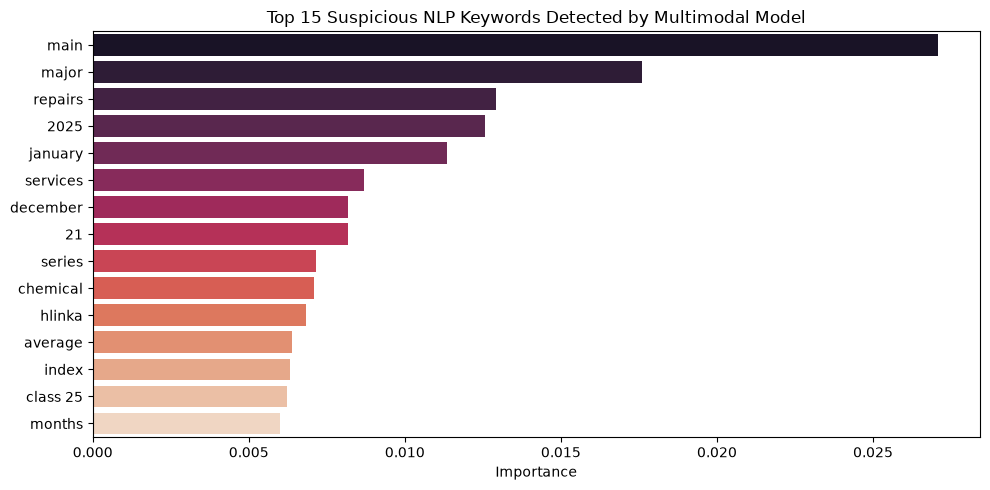

In [39]:
plt.figure(figsize=(10, 5))
sns.barplot(x=text_importances.values, y=[w.replace('text_', '') for w in text_importances.index], palette="rocket")
plt.title("Top 15 Suspicious NLP Keywords Detected by Multimodal Model")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()